# SEIRS-SEI Malaria Model - Weekly Free Force-of-Infection (beta) Calibration

**Diagnostic for any year.** Set `YEAR` in the configuration cell to analyze different years.
The current calibration assumes the force of infection is climate-driven: 
`foi_h = a(T)·b2·(I_M/N)` and `foi_m = a(T)·b1·(I_H/N)`, i.e. a scalar transmission `b` 
multiplied by a temperature-dependent biting rate `a(T)`.

To test that assumption, this notebook instead lets the **effective transmission
coefficients `beta_h` (human infection) and `beta_m` (mosquito infection) be free
parameters, one value per week**, estimated with `lmfit` (least_squares). All
other parameters are fixed at the refined values from `lmfit_results.json` for
the selected year.

The fitted per-week `beta(t)` is then compared against the climate-driven beta
(`a(T)·b1`, `a(T)·b2`) to locate where the climate formulation deviates.

## Step 1 - Imports

`weekly_beta_optimization.py` reuses the shared module
(`lmfit_optimization_shared.py`): same data, same ODE, same weighting. It adds:
- `load_refined_params()`: the fixed parameters (from `lmfit_results.json`) for any year
- `climate_beta_daily / climate_beta_weekly(...)`: the climate-driven reference beta
- `fit_weekly_betas(...)`: the lmfit least-squares fit of the weekly betas
- `run_weekly_beta_fit(...)`: end-to-end fit + save `weekly_beta_results_{year}.json`

In [3]:
import matplotlib.pyplot as plt
from weekly_beta_optimization import *
%matplotlib inline
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

Climate data 2017-2023: 2556 days
Cases data 2017-2023: 2556 rows
lmfit version: 1.3.2

2017 direct start (no warm-up): N=8369, M'=334760 (40.00 x N)
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=76994, E_M=5022, I_M=1674


In [4]:
# ---------------------------------------------------------------------------
# Year Configuration
# ---------------------------------------------------------------------------
# Set the year you want to analyze (must have available data)
YEAR = 2017  # Change this to any year with available data (e.g., 2018, 2019, etc.)

# Validate year has data
try:
    obs = observed_for_year(YEAR)
    if len(obs) == 0:
        raise ValueError(f"No case data for year {YEAR}")
    start = f"{YEAR}-01-01"
    end = f"{YEAR}-12-31"
    clim = climate_data[
        (climate_data["date"] >= start) & (climate_data["date"] <= end)
    ]
    if len(clim) == 0:
        raise ValueError(f"No climate data for year {YEAR}")
    print(f"✓ Year {YEAR} has available data")
except Exception as e:
    print(f"✗ Error: {e}")
    print(f"Available years: {sorted(rural_cases_df['date'].dt.year.unique())}")

✓ Year 2017 has available data


## Step 2 - Fixed yearly parameters (from the refined lmfit calibration)

`b1` and `b2` are NOT used during the weekly fit; they are only kept to build the
climate-driven reference beta. `H0, k, phi, tau_H, gamma, omega, M_prime` and the
IC fractions are fixed at the refined values.

In [6]:
fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
print(f'Fixed params for {YEAR} (from lmfit_results.json):')
for k, v in fixed.items():
    print(f'  {k:<8}= {v:.6g}')
print(f'Climate-driven scalars: b1={b1:.6g}, b2={b2:.6g}')
print('IC fractions:', {k: f'{v:.6g}' for k, v in fracs.items()})
print('Initial state:', state0)
print(f'Year days: {days_in_year(YEAR)}, weekly buckets: {n_weeks_in_year(YEAR)}')

Fixed params for 2017 (from lmfit_results.json):
  H0      = 37.575
  k       = 0.705398
  phi     = 0.215481
  tau_H   = 19.8062
  gamma   = 0.00714852
  omega   = 0.0855217
  M_prime = 50722.6
Climate-driven scalars: b1=0.258903, b2=0.0349827
IC fractions: {'S_H0_frac': '0.301767', 'E_H0_frac': '0.0010153', 'I_M0_ratio': '0.00245356'}
Initial state: [ 2525     8   944  4892 82870   615   205]
Year days: 365, weekly buckets: 53


## Step 3 - Climate-driven beta (current method reference)

`beta_h_clim(t) = a(T)·b2`, `beta_m_clim(t) = a(T)·b1` with the raw daily
temperature used by the ODE. Shown as daily curves (smooth) and as the
weekly-mean values used to seed the free fit.

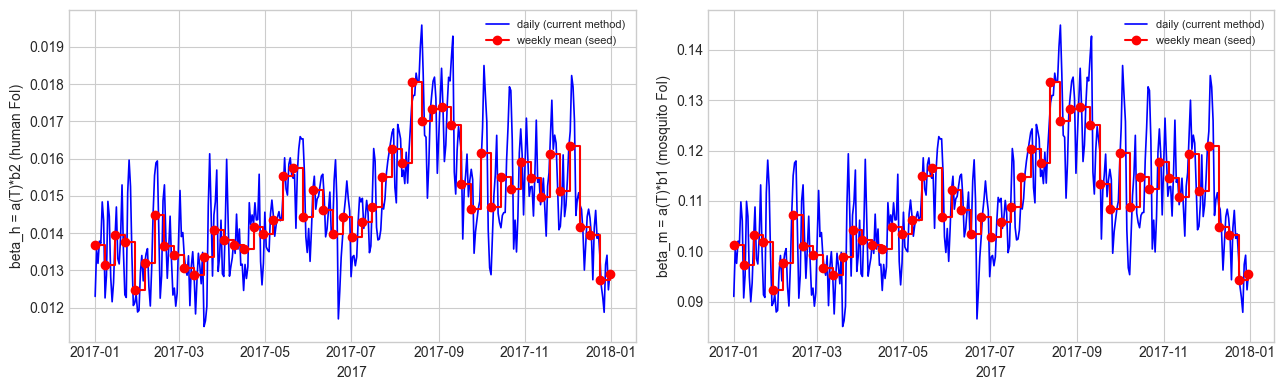

Climate beta_h weekly range: [0.01248, 0.01804]
Climate beta_m weekly range: [0.09236, 0.13354]


In [8]:
nw = n_weeks_in_year(YEAR)
bh_daily, bm_daily = climate_beta_daily(YEAR, b1, b2)
bh_week, bm_week = climate_beta_weekly(YEAR, b1, b2, nw)
dates_year = observed_for_year(YEAR)['date']
week_starts = dates_year[::7][:nw]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ylab, d, w in [
    (axes[0], 'beta_h = a(T)*b2 (human FoI)', bh_daily, bh_week),
    (axes[1], 'beta_m = a(T)*b1 (mosquito FoI)', bm_daily, bm_week),
]:
    ax.plot(dates_year, d, 'b-', lw=1.2, label='daily (current method)')
    ax.step(week_starts, w, 'r-o', where='post', label='weekly mean (seed)')
    ax.set_ylabel(ylab)
    ax.set_xlabel(str(YEAR))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'Climate beta_h weekly range: [{bh_week.min():.5f}, {bh_week.max():.5f}]')
print(f'Climate beta_m weekly range: [{bm_week.min():.5f}, {bm_week.max():.5f}]')

## Step 4 - lmfit least-squares fit of the free weekly betas

- **106 free parameters** (`beta_h` and `beta_m` for each of the 53 weekly buckets).
- Seeded from the weekly-mean climate beta above.
- Objective = weighted residuals against the 365 daily observed cases
  (same exponential early-emphasis weighting as the yearly calibration).
- `max_nfev` caps the solver budget (default 1200; `success=False` only means the
  budget was hit before full convergence).

This cell is the long step (~5-15 min).

In [10]:
QUICK = False
MAX_NFEV = 300 if QUICK else 1200
WEIGHT_KW = dict(DEFAULT_WEIGHT_KW)

print(f'Fitting 2x{n_weeks_in_year(YEAR)} free weekly betas for {YEAR} with lmfit least_squares (max_nfev={MAX_NFEV})...')

payload = run_weekly_beta_fit(
    year=YEAR,  
    weight_kw=WEIGHT_KW,
    max_nfev=MAX_NFEV,
    verbose=True,
)

# Load results for display
res = load_weekly_results(YEAR)  # Updated function
if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")

Fitting 2x53 free weekly betas for 2017 with lmfit least_squares (max_nfev=1200)...
Year 2017: Baseline wMSE (climate-driven beta): 85,035.9
Fitting 106 free weekly betas (beta_h, beta_m)...
Fit done: wMSE = 618.0 (nfev=1200, success=False)
Saved results to weekly_beta_results_2017.json
Year: 2017  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 85,035.9
Weekly-fit wMSE (free beta(t)): 618.0


## Step 5 - Results summary

`baseline_wmse` is the weighted MSE with the climate-driven beta (refined 2017
params) - it reproduces `lmfit_results.json`. `weekly_fit_wmse` is the value after
freeing the weekly betas. The gap shows how much of the misfit is due to the
climate formulation of beta.

In [12]:
res = load_weekly_results(YEAR)  

if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")
    if res['baseline_wmse'] > 0:
        reduction = (1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100
        print(f"wMSE reduction: {reduction:,.1f}%")
    print(f"lmfit: nfev={res['nfev']}, success={res['success']}, chisqr={res['chisqr']:.4g}")

Year: 2017  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 85,035.9
Weekly-fit wMSE (free beta(t)): 618.0
wMSE reduction: 99.3%
lmfit: nfev=1200, success=False, chisqr=8.691e+05


## Step 6 - Fitted weekly beta vs climate-driven beta

Where the fitted free `beta(t)` departs from `a(T)·b1` / `a(T)·b2` indicates
where the climate formulation is missing or misspecified (e.g. a lag between
rainfall and breeding, or a non-temperature mechanism).

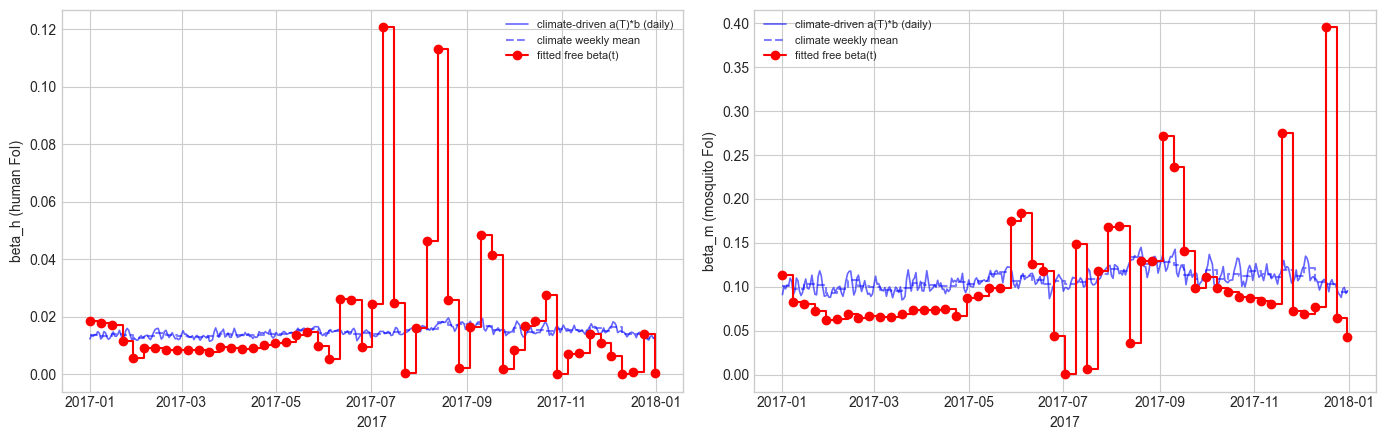

 week       date  beta_h_climate  beta_h_fitted  beta_m_climate  beta_m_fitted
    0 2017-01-01          0.0137         0.0186          0.1012         0.1138
    1 2017-01-08          0.0132         0.0179          0.0974         0.0829
    2 2017-01-15          0.0140         0.0170          0.1033         0.0800
    3 2017-01-22          0.0138         0.0116          0.1019         0.0720
    4 2017-01-29          0.0125         0.0057          0.0924         0.0618
    5 2017-02-05          0.0132         0.0090          0.0977         0.0634
    6 2017-02-12          0.0145         0.0093          0.1073         0.0690
    7 2017-02-19          0.0137         0.0084          0.1011         0.0647
    8 2017-02-26          0.0134         0.0083          0.0992         0.0673
    9 2017-03-05          0.0131         0.0083          0.0966         0.0656
   10 2017-03-12          0.0129         0.0084          0.0953         0.0660
   11 2017-03-19          0.0134         0.0079     

In [14]:
res = load_weekly_results(YEAR)
if res:
    # Get the fitted betas
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    bh_cli = np.array(res['beta_h_weekly_climate'])
    bm_cli = np.array(res['beta_m_weekly_climate'])
    nw = len(bh_fit)
    dates_year = observed_for_year(YEAR)['date']
    week_starts = dates_year[::7][:nw]
    
    bh_daily, bm_daily = climate_beta_daily(
        YEAR, res['climate_params']['b1'], res['climate_params']['b2']
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, name, fit, cli_week, cli_daily in [
        (axes[0], 'beta_h (human FoI)', bh_fit, bh_cli, bh_daily),
        (axes[1], 'beta_m (mosquito FoI)', bm_fit, bm_cli, bm_daily),
    ]:
        ax.plot(dates_year, cli_daily, 'b-', lw=1.2, alpha=0.6, 
                label='climate-driven a(T)*b (daily)')
        ax.step(week_starts, cli_week, 'b--', where='post', alpha=0.5, 
                label='climate weekly mean')
        ax.step(week_starts, fit, 'r-o', where='post', label='fitted free beta(t)')
        ax.set_ylabel(name)
        ax.set_xlabel(str(YEAR))
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    # Table
    tbl = pd.DataFrame({
        'week': np.arange(nw),
        'date': week_starts.values,
        'beta_h_climate': bh_cli,
        'beta_h_fitted': bh_fit,
        'beta_m_climate': bm_cli,
        'beta_m_fitted': bm_fit,
    })
    print(tbl.round(4).to_string(index=False))

## Step 7 - Model vs observed cases with the free weekly beta

Overlaying the model trajectory (with free weekly beta) on the observed cases.

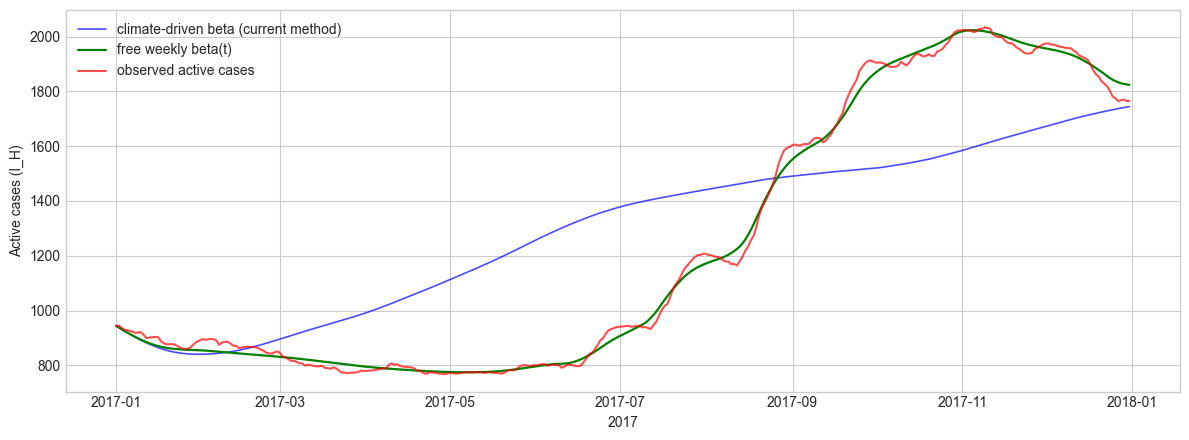

In [16]:
res = load_weekly_results(YEAR)
if res:
    fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    
    dates, IH, _ = simulate_year(YEAR, state0, fixed, bh_fit, bm_fit)
    obs = observed_for_year(YEAR)
    
    full = dict(fixed)
    full['b1'], full['b2'] = b1, b2
    dates0, IH0, _ = simulate_year(YEAR, state0, full)
    
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(pd.to_datetime(dates0), IH0, 'b-', lw=1.2, alpha=0.7, 
            label='climate-driven beta (current method)')
    ax.plot(pd.to_datetime(dates), IH, 'g-', lw=1.6, 
            label='free weekly beta(t)')
    ax.plot(obs['date'], obs['active_total'], 'r-', alpha=0.7, 
            label='observed active cases')
    ax.set_ylabel('Active cases (I_H)')
    ax.set_xlabel(str(YEAR))
    ax.legend()
    plt.tight_layout()
    plt.show()

## Notes

- `success=False` just means the least_squares evaluation budget was reached; the
  reported betas are the best found within that budget.
- The free weekly beta can absorb any mechanism the fixed climate formulation
  misses (lagged rain effects, behaviour, reporting artefacts), so a large wMSE
  improvement only localises *where* the formulation fails - it is not a
  predictive model.
- Results are saved to `weekly_beta_results.json`.
- To change the weighting or the fit budget, edit `WEIGHT_KW` / `MAX_NFEV` in
  Step 4 and re-run from there.

## Step 8 - Analyze multiple years

### 2018

In [20]:
# ---------------------------------------------------------------------------
# Year Configuration
# ---------------------------------------------------------------------------
# Set the year you want to analyze (must have available data)
YEAR = 2018  # Change this to any year with available data (e.g., 2018, 2019, etc.)

# Validate year has data
try:
    obs = observed_for_year(YEAR)
    if len(obs) == 0:
        raise ValueError(f"No case data for year {YEAR}")
    start = f"{YEAR}-01-01"
    end = f"{YEAR}-12-31"
    clim = climate_data[
        (climate_data["date"] >= start) & (climate_data["date"] <= end)
    ]
    if len(clim) == 0:
        raise ValueError(f"No climate data for year {YEAR}")
    print(f"✓ Year {YEAR} has available data")
except Exception as e:
    print(f"✗ Error: {e}")
    print(f"Available years: {sorted(rural_cases_df['date'].dt.year.unique())}")

✓ Year 2018 has available data


In [21]:
fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
print(f'Fixed params for {YEAR} (from lmfit_results.json):')
for k, v in fixed.items():
    print(f'  {k:<8}= {v:.6g}')
print(f'Climate-driven scalars: b1={b1:.6g}, b2={b2:.6g}')
print('IC fractions:', {k: f'{v:.6g}' for k, v in fracs.items()})
print('Initial state:', state0)
print(f'Year days: {days_in_year(YEAR)}, weekly buckets: {n_weeks_in_year(YEAR)}')

Fixed params for 2018 (from lmfit_results.json):
  H0      = 20.3625
  k       = 0.0461343
  phi     = 0.490389
  tau_H   = 19.9977
  gamma   = 0.00733682
  omega   = 0.0961196
  M_prime = 51245
Climate-driven scalars: b1=0.487466, b2=0.0216772
IC fractions: {'S_H0_frac': '0.750265', 'E_H0_frac': '0.034291', 'I_M0_ratio': '0.0181966'}
Initial state: [ 6197.18531276   283.2436411   1765.           143.67380027
 37104.408129    5000.15578774  1503.0392766 ]
Year days: 365, weekly buckets: 53


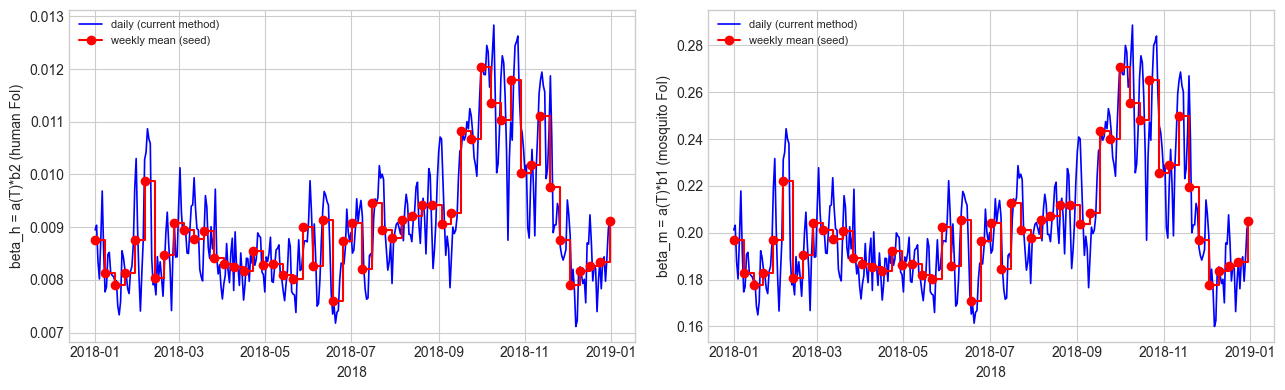

Climate beta_h weekly range: [0.00759, 0.01204]
Climate beta_m weekly range: [0.17072, 0.27078]


In [22]:
nw = n_weeks_in_year(YEAR)
bh_daily, bm_daily = climate_beta_daily(YEAR, b1, b2)
bh_week, bm_week = climate_beta_weekly(YEAR, b1, b2, nw)
dates_year = observed_for_year(YEAR)['date']
week_starts = dates_year[::7][:nw]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ylab, d, w in [
    (axes[0], 'beta_h = a(T)*b2 (human FoI)', bh_daily, bh_week),
    (axes[1], 'beta_m = a(T)*b1 (mosquito FoI)', bm_daily, bm_week),
]:
    ax.plot(dates_year, d, 'b-', lw=1.2, label='daily (current method)')
    ax.step(week_starts, w, 'r-o', where='post', label='weekly mean (seed)')
    ax.set_ylabel(ylab)
    ax.set_xlabel(str(YEAR))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'Climate beta_h weekly range: [{bh_week.min():.5f}, {bh_week.max():.5f}]')
print(f'Climate beta_m weekly range: [{bm_week.min():.5f}, {bm_week.max():.5f}]')

In [23]:
QUICK = False
MAX_NFEV = 300 if QUICK else 1200
WEIGHT_KW = dict(DEFAULT_WEIGHT_KW)

print(f'Fitting 2x{n_weeks_in_year(YEAR)} free weekly betas for {YEAR} with lmfit least_squares (max_nfev={MAX_NFEV})...')

payload = run_weekly_beta_fit(
    year=YEAR,  
    weight_kw=WEIGHT_KW,
    max_nfev=MAX_NFEV,
    verbose=True,
)

# Load results for display
res = load_weekly_results(YEAR)  # Updated function
if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")

Fitting 2x53 free weekly betas for 2018 with lmfit least_squares (max_nfev=1200)...
Year 2018: Baseline wMSE (climate-driven beta): 64,959.5
Fitting 106 free weekly betas (beta_h, beta_m)...
Fit done: wMSE = 2,553.2 (nfev=1200, success=False)
Saved results to weekly_beta_results_2018.json
Year: 2018  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 64,959.5
Weekly-fit wMSE (free beta(t)): 2,553.2


In [24]:
res = load_weekly_results(YEAR)  

if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")
    if res['baseline_wmse'] > 0:
        reduction = (1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100
        print(f"wMSE reduction: {reduction:,.1f}%")
    print(f"lmfit: nfev={res['nfev']}, success={res['success']}, chisqr={res['chisqr']:.4g}")

Year: 2018  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 64,959.5
Weekly-fit wMSE (free beta(t)): 2,553.2
wMSE reduction: 96.1%
lmfit: nfev=1200, success=False, chisqr=3.591e+06


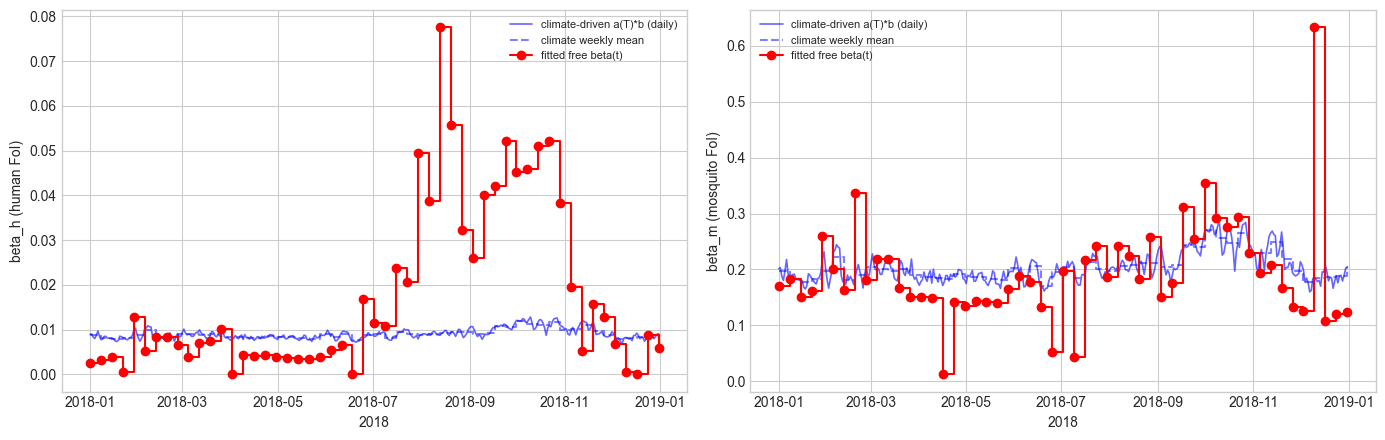

 week       date  beta_h_climate  beta_h_fitted  beta_m_climate  beta_m_fitted
    0 2018-01-01          0.0088         0.0026          0.1971         0.1700
    1 2018-01-08          0.0081         0.0031          0.1828         0.1828
    2 2018-01-15          0.0079         0.0038          0.1779         0.1505
    3 2018-01-22          0.0081         0.0005          0.1829         0.1610
    4 2018-01-29          0.0088         0.0129          0.1971         0.2591
    5 2018-02-05          0.0099         0.0053          0.2221         0.2012
    6 2018-02-12          0.0080         0.0083          0.1807         0.1627
    7 2018-02-19          0.0085         0.0085          0.1903         0.3362
    8 2018-02-26          0.0091         0.0066          0.2042         0.1812
    9 2018-03-05          0.0090         0.0039          0.2013         0.2188
   10 2018-03-12          0.0088         0.0070          0.1974         0.2184
   11 2018-03-19          0.0089         0.0075     

In [25]:
res = load_weekly_results(YEAR)
if res:
    # Get the fitted betas
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    bh_cli = np.array(res['beta_h_weekly_climate'])
    bm_cli = np.array(res['beta_m_weekly_climate'])
    nw = len(bh_fit)
    dates_year = observed_for_year(YEAR)['date']
    week_starts = dates_year[::7][:nw]
    
    bh_daily, bm_daily = climate_beta_daily(
        YEAR, res['climate_params']['b1'], res['climate_params']['b2']
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, name, fit, cli_week, cli_daily in [
        (axes[0], 'beta_h (human FoI)', bh_fit, bh_cli, bh_daily),
        (axes[1], 'beta_m (mosquito FoI)', bm_fit, bm_cli, bm_daily),
    ]:
        ax.plot(dates_year, cli_daily, 'b-', lw=1.2, alpha=0.6, 
                label='climate-driven a(T)*b (daily)')
        ax.step(week_starts, cli_week, 'b--', where='post', alpha=0.5, 
                label='climate weekly mean')
        ax.step(week_starts, fit, 'r-o', where='post', label='fitted free beta(t)')
        ax.set_ylabel(name)
        ax.set_xlabel(str(YEAR))
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    # Table
    tbl = pd.DataFrame({
        'week': np.arange(nw),
        'date': week_starts.values,
        'beta_h_climate': bh_cli,
        'beta_h_fitted': bh_fit,
        'beta_m_climate': bm_cli,
        'beta_m_fitted': bm_fit,
    })
    print(tbl.round(4).to_string(index=False))

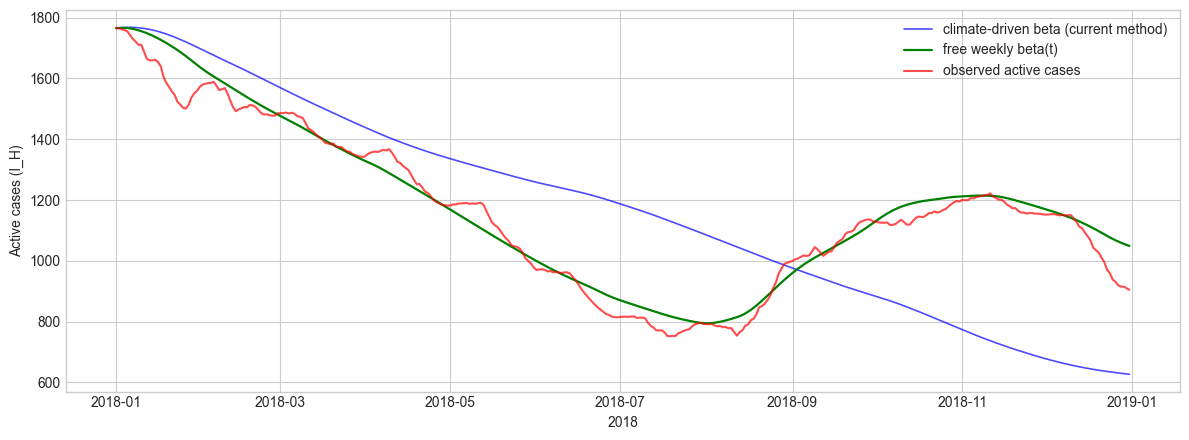

In [26]:
res = load_weekly_results(YEAR)
if res:
    fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    
    dates, IH, _ = simulate_year(YEAR, state0, fixed, bh_fit, bm_fit)
    obs = observed_for_year(YEAR)
    
    full = dict(fixed)
    full['b1'], full['b2'] = b1, b2
    dates0, IH0, _ = simulate_year(YEAR, state0, full)
    
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(pd.to_datetime(dates0), IH0, 'b-', lw=1.2, alpha=0.7, 
            label='climate-driven beta (current method)')
    ax.plot(pd.to_datetime(dates), IH, 'g-', lw=1.6, 
            label='free weekly beta(t)')
    ax.plot(obs['date'], obs['active_total'], 'r-', alpha=0.7, 
            label='observed active cases')
    ax.set_ylabel('Active cases (I_H)')
    ax.set_xlabel(str(YEAR))
    ax.legend()
    plt.tight_layout()
    plt.show()

### 2019

In [28]:
# ---------------------------------------------------------------------------
# Year Configuration
# ---------------------------------------------------------------------------
# Set the year you want to analyze (must have available data)
YEAR = 2019  # Change this to any year with available data (e.g., 2018, 2019, etc.)

# Validate year has data
try:
    obs = observed_for_year(YEAR)
    if len(obs) == 0:
        raise ValueError(f"No case data for year {YEAR}")
    start = f"{YEAR}-01-01"
    end = f"{YEAR}-12-31"
    clim = climate_data[
        (climate_data["date"] >= start) & (climate_data["date"] <= end)
    ]
    if len(clim) == 0:
        raise ValueError(f"No climate data for year {YEAR}")
    print(f"✓ Year {YEAR} has available data")
except Exception as e:
    print(f"✗ Error: {e}")
    print(f"Available years: {sorted(rural_cases_df['date'].dt.year.unique())}")

✓ Year 2019 has available data


In [29]:
fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
print(f'Fixed params for {YEAR} (from lmfit_results.json):')
for k, v in fixed.items():
    print(f'  {k:<8}= {v:.6g}')
print(f'Climate-driven scalars: b1={b1:.6g}, b2={b2:.6g}')
print('IC fractions:', {k: f'{v:.6g}' for k, v in fracs.items()})
print('Initial state:', state0)
print(f'Year days: {days_in_year(YEAR)}, weekly buckets: {n_weeks_in_year(YEAR)}')

Fixed params for 2019 (from lmfit_results.json):
  H0      = 22.1348
  k       = 0.0525881
  phi     = 0.49304
  tau_H   = 19.9582
  gamma   = 0.00720777
  omega   = 0.0744312
  M_prime = 50473.6
Climate-driven scalars: b1=0.487539, b2=0.021604
IC fractions: {'S_H0_frac': '0.93709', 'E_H0_frac': '0.00895245', 'I_M0_ratio': '0.00654346'}
Initial state: [ 7640.09798054    72.98930864   901.            49.00690799
 33757.62905208  3114.89371466   533.48808427]
Year days: 365, weekly buckets: 53


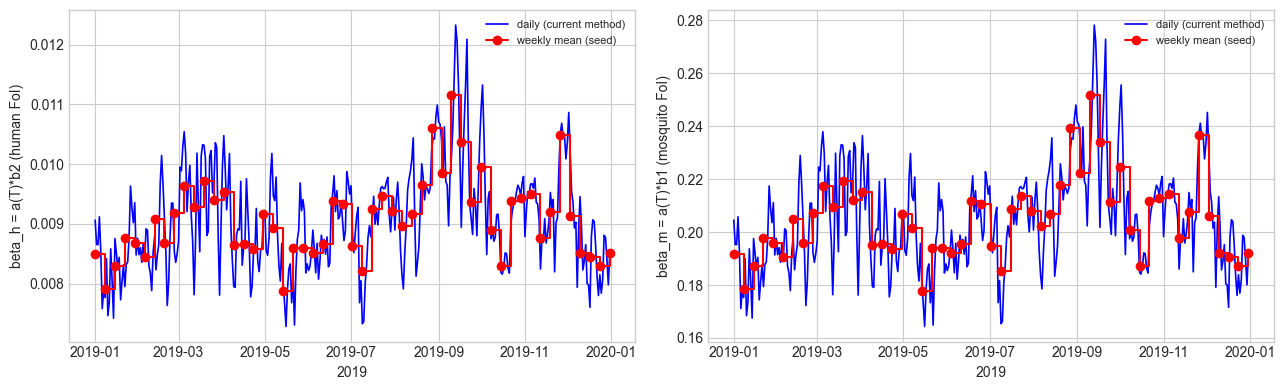

Climate beta_h weekly range: [0.00787, 0.01116]
Climate beta_m weekly range: [0.17763, 0.25190]


In [30]:
nw = n_weeks_in_year(YEAR)
bh_daily, bm_daily = climate_beta_daily(YEAR, b1, b2)
bh_week, bm_week = climate_beta_weekly(YEAR, b1, b2, nw)
dates_year = observed_for_year(YEAR)['date']
week_starts = dates_year[::7][:nw]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ylab, d, w in [
    (axes[0], 'beta_h = a(T)*b2 (human FoI)', bh_daily, bh_week),
    (axes[1], 'beta_m = a(T)*b1 (mosquito FoI)', bm_daily, bm_week),
]:
    ax.plot(dates_year, d, 'b-', lw=1.2, label='daily (current method)')
    ax.step(week_starts, w, 'r-o', where='post', label='weekly mean (seed)')
    ax.set_ylabel(ylab)
    ax.set_xlabel(str(YEAR))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'Climate beta_h weekly range: [{bh_week.min():.5f}, {bh_week.max():.5f}]')
print(f'Climate beta_m weekly range: [{bm_week.min():.5f}, {bm_week.max():.5f}]')

In [31]:
QUICK = False
MAX_NFEV = 300 if QUICK else 1200
WEIGHT_KW = dict(DEFAULT_WEIGHT_KW)

print(f'Fitting 2x{n_weeks_in_year(YEAR)} free weekly betas for {YEAR} with lmfit least_squares (max_nfev={MAX_NFEV})...')

payload = run_weekly_beta_fit(
    year=YEAR,  
    weight_kw=WEIGHT_KW,
    max_nfev=MAX_NFEV,
    verbose=True,
)

# Load results for display
res = load_weekly_results(YEAR)  # Updated function
if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")

Fitting 2x53 free weekly betas for 2019 with lmfit least_squares (max_nfev=1200)...
Year 2019: Baseline wMSE (climate-driven beta): 41,436.1
Fitting 106 free weekly betas (beta_h, beta_m)...
Fit done: wMSE = 560.9 (nfev=1200, success=False)
Saved results to weekly_beta_results_2019.json
Year: 2019  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 41,436.1
Weekly-fit wMSE (free beta(t)): 560.9


In [32]:
res = load_weekly_results(YEAR)  

if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")
    if res['baseline_wmse'] > 0:
        reduction = (1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100
        print(f"wMSE reduction: {reduction:,.1f}%")
    print(f"lmfit: nfev={res['nfev']}, success={res['success']}, chisqr={res['chisqr']:.4g}")

Year: 2019  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 41,436.1
Weekly-fit wMSE (free beta(t)): 560.9
wMSE reduction: 98.6%
lmfit: nfev=1200, success=False, chisqr=7.888e+05


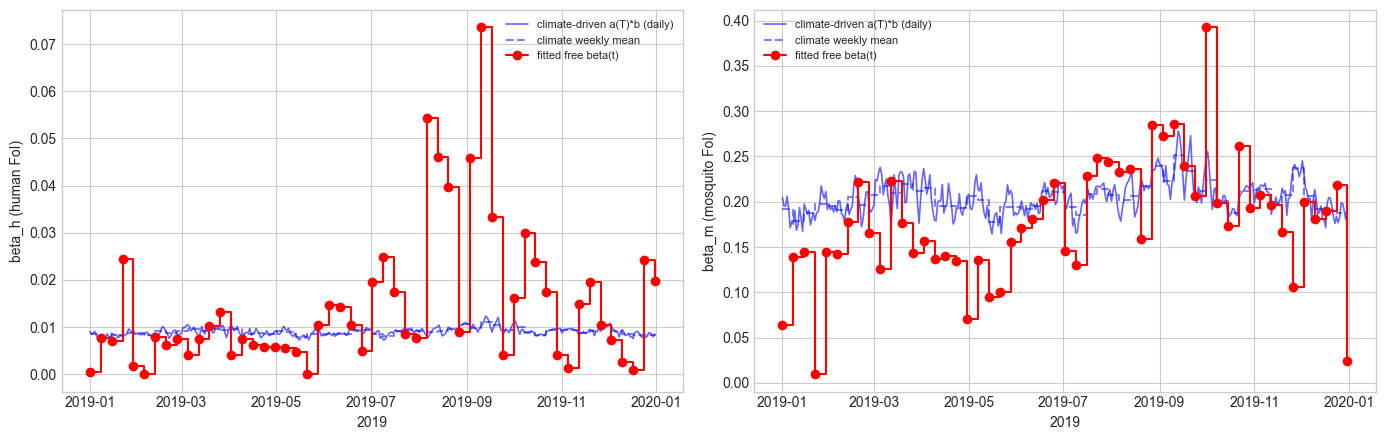

 week       date  beta_h_climate  beta_h_fitted  beta_m_climate  beta_m_fitted
    0 2019-01-01          0.0085         0.0006          0.1918         0.0640
    1 2019-01-08          0.0079         0.0077          0.1785         0.1395
    2 2019-01-15          0.0083         0.0070          0.1871         0.1445
    3 2019-01-22          0.0088         0.0245          0.1977         0.0095
    4 2019-01-29          0.0087         0.0018          0.1957         0.1449
    5 2019-02-05          0.0084         0.0001          0.1905         0.1418
    6 2019-02-12          0.0091         0.0079          0.2051         0.1773
    7 2019-02-19          0.0087         0.0063          0.1960         0.2214
    8 2019-02-26          0.0092         0.0075          0.2071         0.1652
    9 2019-03-05          0.0096         0.0042          0.2174         0.1254
   10 2019-03-12          0.0093         0.0075          0.2095         0.2232
   11 2019-03-19          0.0097         0.0102     

In [33]:
res = load_weekly_results(YEAR)
if res:
    # Get the fitted betas
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    bh_cli = np.array(res['beta_h_weekly_climate'])
    bm_cli = np.array(res['beta_m_weekly_climate'])
    nw = len(bh_fit)
    dates_year = observed_for_year(YEAR)['date']
    week_starts = dates_year[::7][:nw]
    
    bh_daily, bm_daily = climate_beta_daily(
        YEAR, res['climate_params']['b1'], res['climate_params']['b2']
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, name, fit, cli_week, cli_daily in [
        (axes[0], 'beta_h (human FoI)', bh_fit, bh_cli, bh_daily),
        (axes[1], 'beta_m (mosquito FoI)', bm_fit, bm_cli, bm_daily),
    ]:
        ax.plot(dates_year, cli_daily, 'b-', lw=1.2, alpha=0.6, 
                label='climate-driven a(T)*b (daily)')
        ax.step(week_starts, cli_week, 'b--', where='post', alpha=0.5, 
                label='climate weekly mean')
        ax.step(week_starts, fit, 'r-o', where='post', label='fitted free beta(t)')
        ax.set_ylabel(name)
        ax.set_xlabel(str(YEAR))
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    # Table
    tbl = pd.DataFrame({
        'week': np.arange(nw),
        'date': week_starts.values,
        'beta_h_climate': bh_cli,
        'beta_h_fitted': bh_fit,
        'beta_m_climate': bm_cli,
        'beta_m_fitted': bm_fit,
    })
    print(tbl.round(4).to_string(index=False))

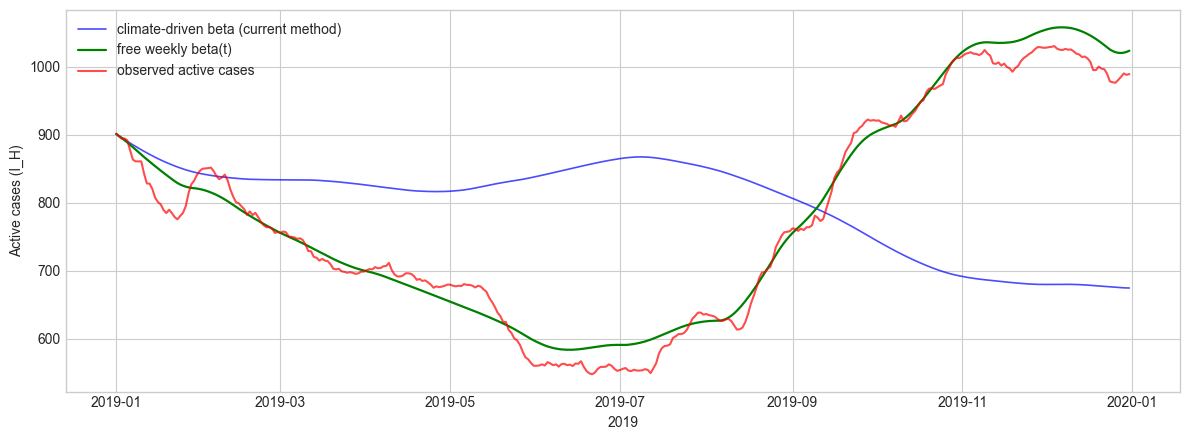

In [34]:
res = load_weekly_results(YEAR)
if res:
    fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    
    dates, IH, _ = simulate_year(YEAR, state0, fixed, bh_fit, bm_fit)
    obs = observed_for_year(YEAR)
    
    full = dict(fixed)
    full['b1'], full['b2'] = b1, b2
    dates0, IH0, _ = simulate_year(YEAR, state0, full)
    
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(pd.to_datetime(dates0), IH0, 'b-', lw=1.2, alpha=0.7, 
            label='climate-driven beta (current method)')
    ax.plot(pd.to_datetime(dates), IH, 'g-', lw=1.6, 
            label='free weekly beta(t)')
    ax.plot(obs['date'], obs['active_total'], 'r-', alpha=0.7, 
            label='observed active cases')
    ax.set_ylabel('Active cases (I_H)')
    ax.set_xlabel(str(YEAR))
    ax.legend()
    plt.tight_layout()
    plt.show()

### 2020

In [36]:
# ---------------------------------------------------------------------------
# Year Configuration
# ---------------------------------------------------------------------------
# Set the year you want to analyze (must have available data)
YEAR = 2020  # Change this to any year with available data (e.g., 2018, 2019, etc.)

# Validate year has data
try:
    obs = observed_for_year(YEAR)
    if len(obs) == 0:
        raise ValueError(f"No case data for year {YEAR}")
    start = f"{YEAR}-01-01"
    end = f"{YEAR}-12-31"
    clim = climate_data[
        (climate_data["date"] >= start) & (climate_data["date"] <= end)
    ]
    if len(clim) == 0:
        raise ValueError(f"No climate data for year {YEAR}")
    print(f"✓ Year {YEAR} has available data")
except Exception as e:
    print(f"✗ Error: {e}")
    print(f"Available years: {sorted(rural_cases_df['date'].dt.year.unique())}")

✓ Year 2020 has available data


In [37]:
fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
print(f'Fixed params for {YEAR} (from lmfit_results.json):')
for k, v in fixed.items():
    print(f'  {k:<8}= {v:.6g}')
print(f'Climate-driven scalars: b1={b1:.6g}, b2={b2:.6g}')
print('IC fractions:', {k: f'{v:.6g}' for k, v in fracs.items()})
print('Initial state:', state0)
print(f'Year days: {days_in_year(YEAR)}, weekly buckets: {n_weeks_in_year(YEAR)}')

Fixed params for 2020 (from lmfit_results.json):
  H0      = 20.1265
  k       = 0.0394834
  phi     = 0.499536
  tau_H   = 19.9766
  gamma   = 0.00674766
  omega   = 0.0422066
  M_prime = 50024.1
Climate-driven scalars: b1=0.49975, b2=0.0192336
IC fractions: {'S_H0_frac': '0.97297', 'E_H0_frac': '0.011845', 'I_M0_ratio': '0.00877001'}
Initial state: [ 7827.54662023    95.29276436   990.            65.64429266
 36902.17503532  3641.14813226   705.54763344]
Year days: 366, weekly buckets: 53


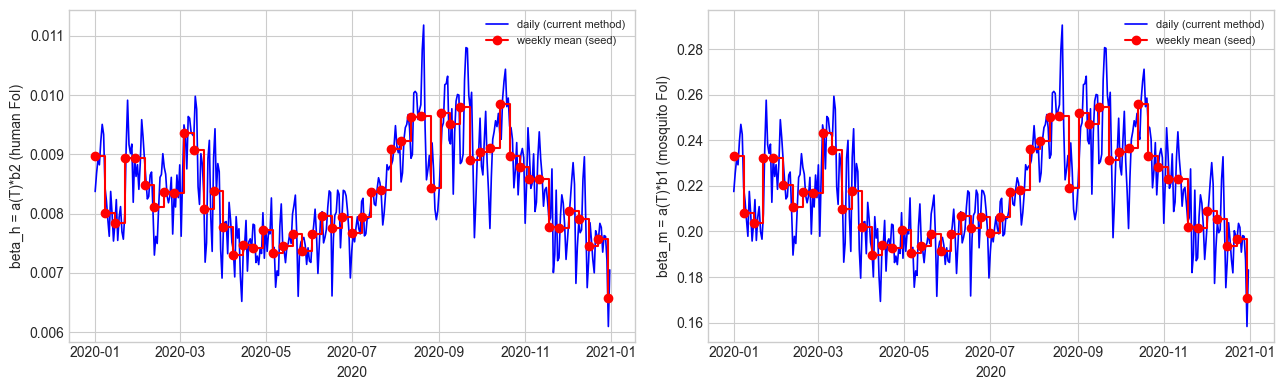

Climate beta_h weekly range: [0.00657, 0.00985]
Climate beta_m weekly range: [0.17074, 0.25603]


In [38]:
nw = n_weeks_in_year(YEAR)
bh_daily, bm_daily = climate_beta_daily(YEAR, b1, b2)
bh_week, bm_week = climate_beta_weekly(YEAR, b1, b2, nw)
dates_year = observed_for_year(YEAR)['date']
week_starts = dates_year[::7][:nw]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ylab, d, w in [
    (axes[0], 'beta_h = a(T)*b2 (human FoI)', bh_daily, bh_week),
    (axes[1], 'beta_m = a(T)*b1 (mosquito FoI)', bm_daily, bm_week),
]:
    ax.plot(dates_year, d, 'b-', lw=1.2, label='daily (current method)')
    ax.step(week_starts, w, 'r-o', where='post', label='weekly mean (seed)')
    ax.set_ylabel(ylab)
    ax.set_xlabel(str(YEAR))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'Climate beta_h weekly range: [{bh_week.min():.5f}, {bh_week.max():.5f}]')
print(f'Climate beta_m weekly range: [{bm_week.min():.5f}, {bm_week.max():.5f}]')

In [39]:
QUICK = False
MAX_NFEV = 300 if QUICK else 1200
WEIGHT_KW = dict(DEFAULT_WEIGHT_KW)

print(f'Fitting 2x{n_weeks_in_year(YEAR)} free weekly betas for {YEAR} with lmfit least_squares (max_nfev={MAX_NFEV})...')

payload = run_weekly_beta_fit(
    year=YEAR,  
    weight_kw=WEIGHT_KW,
    max_nfev=MAX_NFEV,
    verbose=True,
)

# Load results for display
res = load_weekly_results(YEAR)  # Updated function
if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")

Fitting 2x53 free weekly betas for 2020 with lmfit least_squares (max_nfev=1200)...
Year 2020: Baseline wMSE (climate-driven beta): 23,540.8
Fitting 106 free weekly betas (beta_h, beta_m)...
Fit done: wMSE = 358.7 (nfev=1200, success=False)
Saved results to weekly_beta_results_2020.json
Year: 2020  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 23,540.8
Weekly-fit wMSE (free beta(t)): 358.7


In [40]:
res = load_weekly_results(YEAR)  

if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")
    if res['baseline_wmse'] > 0:
        reduction = (1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100
        print(f"wMSE reduction: {reduction:,.1f}%")
    print(f"lmfit: nfev={res['nfev']}, success={res['success']}, chisqr={res['chisqr']:.4g}")

Year: 2020  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 23,540.8
Weekly-fit wMSE (free beta(t)): 358.7
wMSE reduction: 98.5%
lmfit: nfev=1200, success=False, chisqr=5.055e+05


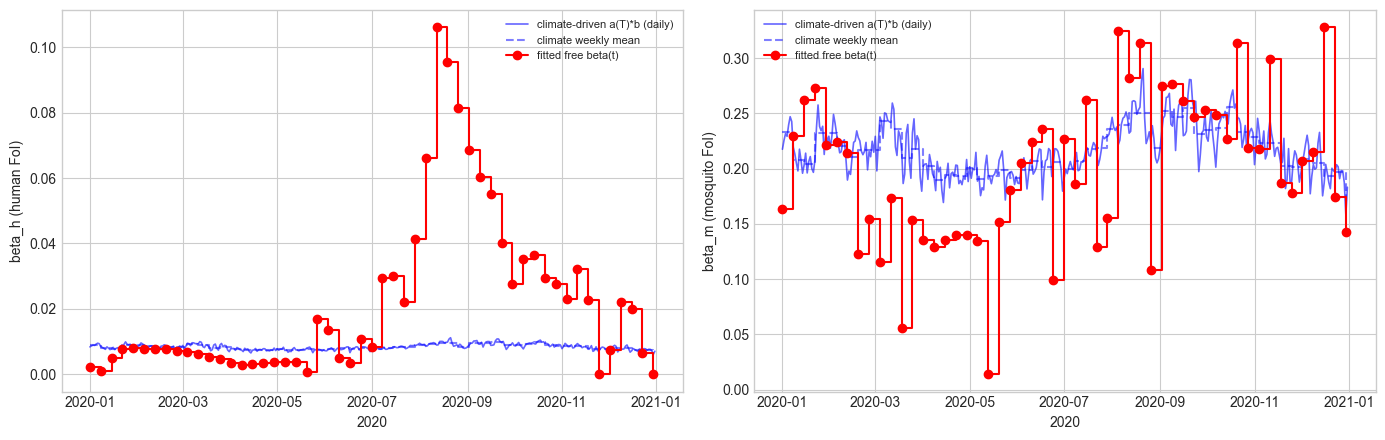

 week       date  beta_h_climate  beta_h_fitted  beta_m_climate  beta_m_fitted
    0 2020-01-01          0.0090         0.0023          0.2333         0.1637
    1 2020-01-08          0.0080         0.0009          0.2081         0.2299
    2 2020-01-15          0.0078         0.0051          0.2038         0.2620
    3 2020-01-22          0.0089         0.0077          0.2323         0.2731
    4 2020-01-29          0.0089         0.0081          0.2321         0.2210
    5 2020-02-05          0.0085         0.0077          0.2206         0.2240
    6 2020-02-12          0.0081         0.0077          0.2108         0.2137
    7 2020-02-19          0.0084         0.0078          0.2171         0.1228
    8 2020-02-26          0.0083         0.0070          0.2167         0.1544
    9 2020-03-04          0.0094         0.0068          0.2433         0.1154
   10 2020-03-11          0.0091         0.0062          0.2357         0.1730
   11 2020-03-18          0.0081         0.0051     

In [41]:
res = load_weekly_results(YEAR)
if res:
    # Get the fitted betas
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    bh_cli = np.array(res['beta_h_weekly_climate'])
    bm_cli = np.array(res['beta_m_weekly_climate'])
    nw = len(bh_fit)
    dates_year = observed_for_year(YEAR)['date']
    week_starts = dates_year[::7][:nw]
    
    bh_daily, bm_daily = climate_beta_daily(
        YEAR, res['climate_params']['b1'], res['climate_params']['b2']
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, name, fit, cli_week, cli_daily in [
        (axes[0], 'beta_h (human FoI)', bh_fit, bh_cli, bh_daily),
        (axes[1], 'beta_m (mosquito FoI)', bm_fit, bm_cli, bm_daily),
    ]:
        ax.plot(dates_year, cli_daily, 'b-', lw=1.2, alpha=0.6, 
                label='climate-driven a(T)*b (daily)')
        ax.step(week_starts, cli_week, 'b--', where='post', alpha=0.5, 
                label='climate weekly mean')
        ax.step(week_starts, fit, 'r-o', where='post', label='fitted free beta(t)')
        ax.set_ylabel(name)
        ax.set_xlabel(str(YEAR))
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    # Table
    tbl = pd.DataFrame({
        'week': np.arange(nw),
        'date': week_starts.values,
        'beta_h_climate': bh_cli,
        'beta_h_fitted': bh_fit,
        'beta_m_climate': bm_cli,
        'beta_m_fitted': bm_fit,
    })
    print(tbl.round(4).to_string(index=False))

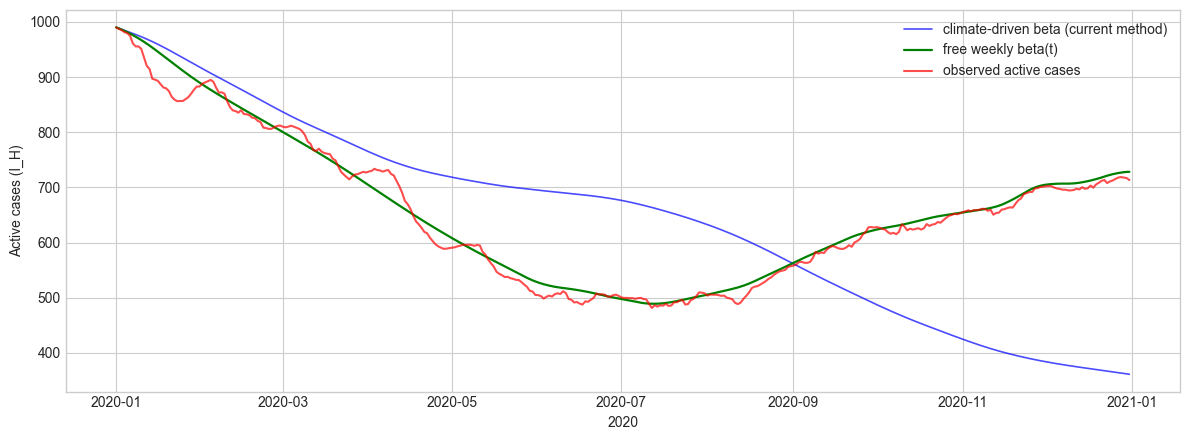

In [42]:
res = load_weekly_results(YEAR)
if res:
    fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    
    dates, IH, _ = simulate_year(YEAR, state0, fixed, bh_fit, bm_fit)
    obs = observed_for_year(YEAR)
    
    full = dict(fixed)
    full['b1'], full['b2'] = b1, b2
    dates0, IH0, _ = simulate_year(YEAR, state0, full)
    
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(pd.to_datetime(dates0), IH0, 'b-', lw=1.2, alpha=0.7, 
            label='climate-driven beta (current method)')
    ax.plot(pd.to_datetime(dates), IH, 'g-', lw=1.6, 
            label='free weekly beta(t)')
    ax.plot(obs['date'], obs['active_total'], 'r-', alpha=0.7, 
            label='observed active cases')
    ax.set_ylabel('Active cases (I_H)')
    ax.set_xlabel(str(YEAR))
    ax.legend()
    plt.tight_layout()
    plt.show()

### 2021

In [44]:
# ---------------------------------------------------------------------------
# Year Configuration
# ---------------------------------------------------------------------------
# Set the year you want to analyze (must have available data)
YEAR = 2021  # Change this to any year with available data (e.g., 2018, 2019, etc.)

# Validate year has data
try:
    obs = observed_for_year(YEAR)
    if len(obs) == 0:
        raise ValueError(f"No case data for year {YEAR}")
    start = f"{YEAR}-01-01"
    end = f"{YEAR}-12-31"
    clim = climate_data[
        (climate_data["date"] >= start) & (climate_data["date"] <= end)
    ]
    if len(clim) == 0:
        raise ValueError(f"No climate data for year {YEAR}")
    print(f"✓ Year {YEAR} has available data")
except Exception as e:
    print(f"✗ Error: {e}")
    print(f"Available years: {sorted(rural_cases_df['date'].dt.year.unique())}")

✓ Year 2021 has available data


In [45]:
fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
print(f'Fixed params for {YEAR} (from lmfit_results.json):')
for k, v in fixed.items():
    print(f'  {k:<8}= {v:.6g}')
print(f'Climate-driven scalars: b1={b1:.6g}, b2={b2:.6g}')
print('IC fractions:', {k: f'{v:.6g}' for k, v in fracs.items()})
print('Initial state:', state0)
print(f'Year days: {days_in_year(YEAR)}, weekly buckets: {n_weeks_in_year(YEAR)}')

Fixed params for 2021 (from lmfit_results.json):
  H0      = 20.0216
  k       = 0.0431056
  phi     = 0.493208
  tau_H   = 19.9897
  gamma   = 0.00673798
  omega   = 0.0773048
  M_prime = 50015.3
Climate-driven scalars: b1=0.499774, b2=0.0192094
IC fractions: {'S_H0_frac': '1.07334', 'E_H0_frac': '0.00434881', 'I_M0_ratio': '0.00281907'}
Initial state: [8.52120944e+03 3.45252334e+01 7.08000000e+02 6.13538112e+01
 3.98799101e+04 1.74878366e+03 2.23805804e+02]
Year days: 365, weekly buckets: 53


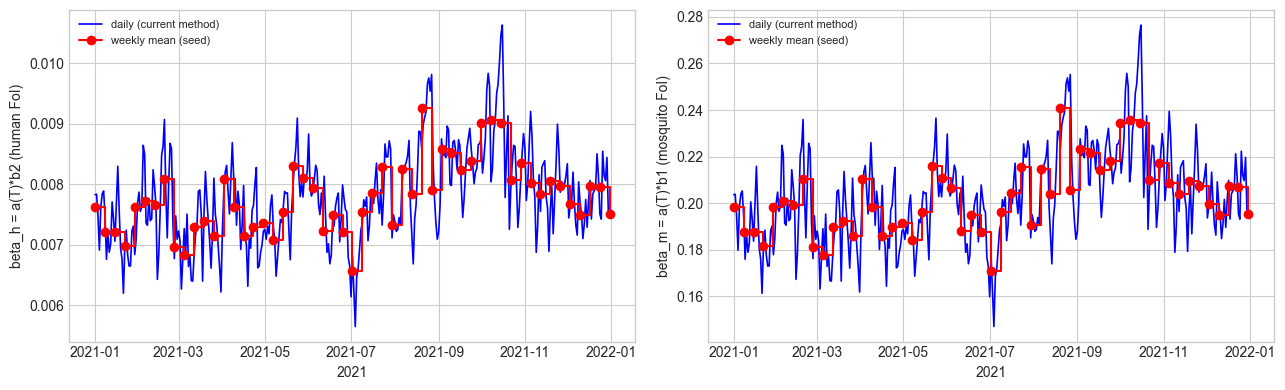

Climate beta_h weekly range: [0.00656, 0.00926]
Climate beta_m weekly range: [0.17076, 0.24085]


In [46]:
nw = n_weeks_in_year(YEAR)
bh_daily, bm_daily = climate_beta_daily(YEAR, b1, b2)
bh_week, bm_week = climate_beta_weekly(YEAR, b1, b2, nw)
dates_year = observed_for_year(YEAR)['date']
week_starts = dates_year[::7][:nw]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ylab, d, w in [
    (axes[0], 'beta_h = a(T)*b2 (human FoI)', bh_daily, bh_week),
    (axes[1], 'beta_m = a(T)*b1 (mosquito FoI)', bm_daily, bm_week),
]:
    ax.plot(dates_year, d, 'b-', lw=1.2, label='daily (current method)')
    ax.step(week_starts, w, 'r-o', where='post', label='weekly mean (seed)')
    ax.set_ylabel(ylab)
    ax.set_xlabel(str(YEAR))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'Climate beta_h weekly range: [{bh_week.min():.5f}, {bh_week.max():.5f}]')
print(f'Climate beta_m weekly range: [{bm_week.min():.5f}, {bm_week.max():.5f}]')

In [47]:
QUICK = False
MAX_NFEV = 300 if QUICK else 1200
WEIGHT_KW = dict(DEFAULT_WEIGHT_KW)

print(f'Fitting 2x{n_weeks_in_year(YEAR)} free weekly betas for {YEAR} with lmfit least_squares (max_nfev={MAX_NFEV})...')

payload = run_weekly_beta_fit(
    year=YEAR,  
    weight_kw=WEIGHT_KW,
    max_nfev=MAX_NFEV,
    verbose=True,
)

# Load results for display
res = load_weekly_results(YEAR)  # Updated function
if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")

Fitting 2x53 free weekly betas for 2021 with lmfit least_squares (max_nfev=1200)...
Year 2021: Baseline wMSE (climate-driven beta): 39,449.1
Fitting 106 free weekly betas (beta_h, beta_m)...
Fit done: wMSE = 1,551.8 (nfev=1200, success=False)
Saved results to weekly_beta_results_2021.json
Year: 2021  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 39,449.1
Weekly-fit wMSE (free beta(t)): 1,551.8


In [48]:
res = load_weekly_results(YEAR)  

if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")
    if res['baseline_wmse'] > 0:
        reduction = (1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100
        print(f"wMSE reduction: {reduction:,.1f}%")
    print(f"lmfit: nfev={res['nfev']}, success={res['success']}, chisqr={res['chisqr']:.4g}")

Year: 2021  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 39,449.1
Weekly-fit wMSE (free beta(t)): 1,551.8
wMSE reduction: 96.1%
lmfit: nfev=1200, success=False, chisqr=2.182e+06


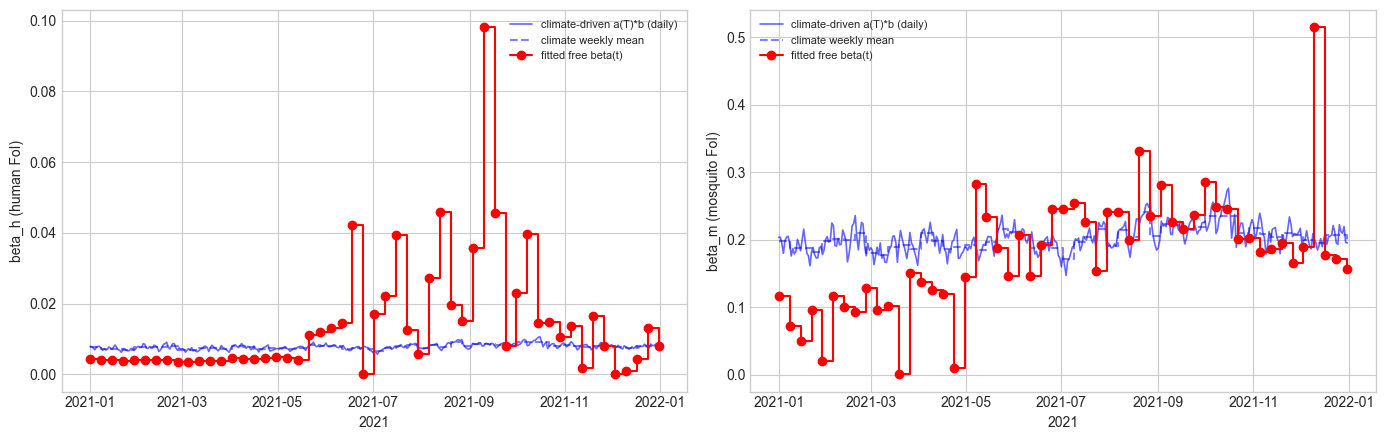

 week       date  beta_h_climate  beta_h_fitted  beta_m_climate  beta_m_fitted
    0 2021-01-01          0.0076         0.0042          0.1985         0.1165
    1 2021-01-08          0.0072         0.0040          0.1875         0.0722
    2 2021-01-15          0.0072         0.0039          0.1877         0.0499
    3 2021-01-22          0.0070         0.0038          0.1818         0.0953
    4 2021-01-29          0.0076         0.0040          0.1982         0.0204
    5 2021-02-05          0.0077         0.0040          0.2007         0.1168
    6 2021-02-12          0.0077         0.0039          0.1991         0.1004
    7 2021-02-19          0.0081         0.0041          0.2104         0.0934
    8 2021-02-26          0.0070         0.0035          0.1810         0.1280
    9 2021-03-05          0.0068         0.0034          0.1779         0.0954
   10 2021-03-12          0.0073         0.0037          0.1896         0.1016
   11 2021-03-19          0.0074         0.0038     

In [49]:
res = load_weekly_results(YEAR)
if res:
    # Get the fitted betas
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    bh_cli = np.array(res['beta_h_weekly_climate'])
    bm_cli = np.array(res['beta_m_weekly_climate'])
    nw = len(bh_fit)
    dates_year = observed_for_year(YEAR)['date']
    week_starts = dates_year[::7][:nw]
    
    bh_daily, bm_daily = climate_beta_daily(
        YEAR, res['climate_params']['b1'], res['climate_params']['b2']
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, name, fit, cli_week, cli_daily in [
        (axes[0], 'beta_h (human FoI)', bh_fit, bh_cli, bh_daily),
        (axes[1], 'beta_m (mosquito FoI)', bm_fit, bm_cli, bm_daily),
    ]:
        ax.plot(dates_year, cli_daily, 'b-', lw=1.2, alpha=0.6, 
                label='climate-driven a(T)*b (daily)')
        ax.step(week_starts, cli_week, 'b--', where='post', alpha=0.5, 
                label='climate weekly mean')
        ax.step(week_starts, fit, 'r-o', where='post', label='fitted free beta(t)')
        ax.set_ylabel(name)
        ax.set_xlabel(str(YEAR))
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    # Table
    tbl = pd.DataFrame({
        'week': np.arange(nw),
        'date': week_starts.values,
        'beta_h_climate': bh_cli,
        'beta_h_fitted': bh_fit,
        'beta_m_climate': bm_cli,
        'beta_m_fitted': bm_fit,
    })
    print(tbl.round(4).to_string(index=False))

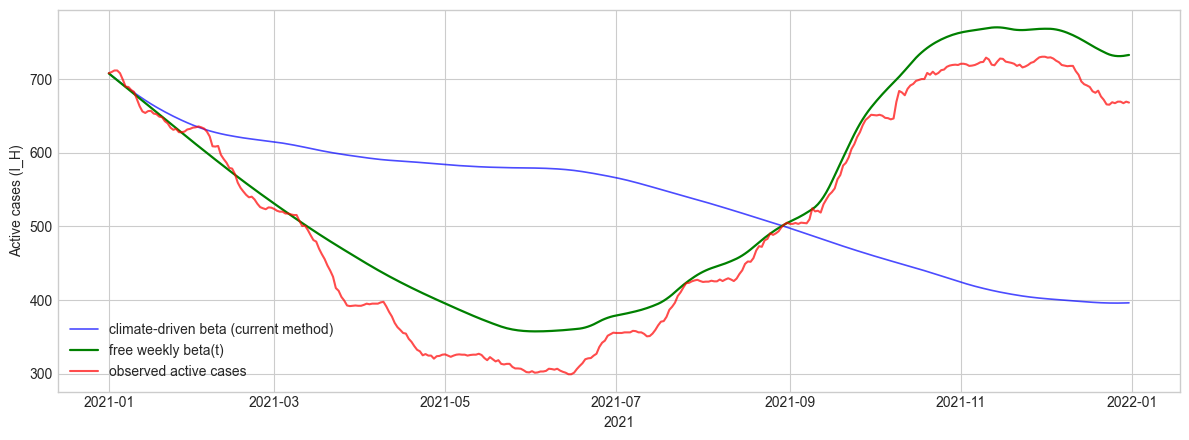

In [50]:
res = load_weekly_results(YEAR)
if res:
    fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    
    dates, IH, _ = simulate_year(YEAR, state0, fixed, bh_fit, bm_fit)
    obs = observed_for_year(YEAR)
    
    full = dict(fixed)
    full['b1'], full['b2'] = b1, b2
    dates0, IH0, _ = simulate_year(YEAR, state0, full)
    
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(pd.to_datetime(dates0), IH0, 'b-', lw=1.2, alpha=0.7, 
            label='climate-driven beta (current method)')
    ax.plot(pd.to_datetime(dates), IH, 'g-', lw=1.6, 
            label='free weekly beta(t)')
    ax.plot(obs['date'], obs['active_total'], 'r-', alpha=0.7, 
            label='observed active cases')
    ax.set_ylabel('Active cases (I_H)')
    ax.set_xlabel(str(YEAR))
    ax.legend()
    plt.tight_layout()
    plt.show()

### 2022

In [52]:
# ---------------------------------------------------------------------------
# Year Configuration
# ---------------------------------------------------------------------------
# Set the year you want to analyze (must have available data)
YEAR = 2022  # Change this to any year with available data (e.g., 2018, 2019, etc.)

# Validate year has data
try:
    obs = observed_for_year(YEAR)
    if len(obs) == 0:
        raise ValueError(f"No case data for year {YEAR}")
    start = f"{YEAR}-01-01"
    end = f"{YEAR}-12-31"
    clim = climate_data[
        (climate_data["date"] >= start) & (climate_data["date"] <= end)
    ]
    if len(clim) == 0:
        raise ValueError(f"No climate data for year {YEAR}")
    print(f"✓ Year {YEAR} has available data")
except Exception as e:
    print(f"✗ Error: {e}")
    print(f"Available years: {sorted(rural_cases_df['date'].dt.year.unique())}")

✓ Year 2022 has available data


In [53]:
fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
print(f'Fixed params for {YEAR} (from lmfit_results.json):')
for k, v in fixed.items():
    print(f'  {k:<8}= {v:.6g}')
print(f'Climate-driven scalars: b1={b1:.6g}, b2={b2:.6g}')
print('IC fractions:', {k: f'{v:.6g}' for k, v in fracs.items()})
print('Initial state:', state0)
print(f'Year days: {days_in_year(YEAR)}, weekly buckets: {n_weeks_in_year(YEAR)}')

Fixed params for 2022 (from lmfit_results.json):
  H0      = 20.0216
  k       = 0.0431056
  phi     = 0.493208
  tau_H   = 19.7732
  gamma   = 0.00987933
  omega   = 0.0311879
  M_prime = 50832.3
Climate-driven scalars: b1=0.499774, b2=0.0192094
IC fractions: {'S_H0_frac': '1.12851', 'E_H0_frac': '0.00711533', 'I_M0_ratio': '0.00467193'}
Initial state: [ 8838.51923899    55.7272678    671.            34.70443441
 34461.06757701  2181.39970983   365.90521814]
Year days: 365, weekly buckets: 53


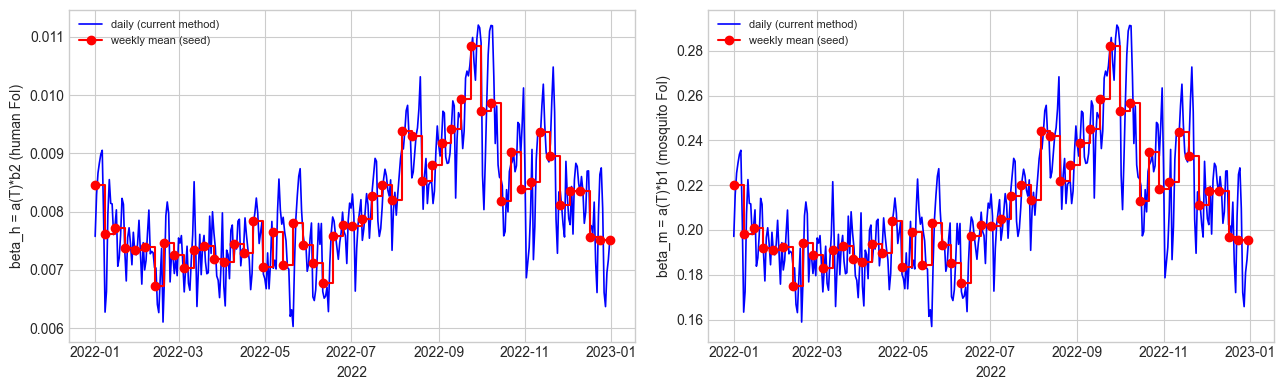

Climate beta_h weekly range: [0.00673, 0.01085]
Climate beta_m weekly range: [0.17497, 0.28217]


In [54]:
nw = n_weeks_in_year(YEAR)
bh_daily, bm_daily = climate_beta_daily(YEAR, b1, b2)
bh_week, bm_week = climate_beta_weekly(YEAR, b1, b2, nw)
dates_year = observed_for_year(YEAR)['date']
week_starts = dates_year[::7][:nw]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ylab, d, w in [
    (axes[0], 'beta_h = a(T)*b2 (human FoI)', bh_daily, bh_week),
    (axes[1], 'beta_m = a(T)*b1 (mosquito FoI)', bm_daily, bm_week),
]:
    ax.plot(dates_year, d, 'b-', lw=1.2, label='daily (current method)')
    ax.step(week_starts, w, 'r-o', where='post', label='weekly mean (seed)')
    ax.set_ylabel(ylab)
    ax.set_xlabel(str(YEAR))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'Climate beta_h weekly range: [{bh_week.min():.5f}, {bh_week.max():.5f}]')
print(f'Climate beta_m weekly range: [{bm_week.min():.5f}, {bm_week.max():.5f}]')

In [55]:
QUICK = False
MAX_NFEV = 300 if QUICK else 1200
WEIGHT_KW = dict(DEFAULT_WEIGHT_KW)

print(f'Fitting 2x{n_weeks_in_year(YEAR)} free weekly betas for {YEAR} with lmfit least_squares (max_nfev={MAX_NFEV})...')

payload = run_weekly_beta_fit(
    year=YEAR,  
    weight_kw=WEIGHT_KW,
    max_nfev=MAX_NFEV,
    verbose=True,
)

# Load results for display
res = load_weekly_results(YEAR)  # Updated function
if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")

Fitting 2x53 free weekly betas for 2022 with lmfit least_squares (max_nfev=1200)...
Year 2022: Baseline wMSE (climate-driven beta): 25,046.3
Fitting 106 free weekly betas (beta_h, beta_m)...
Fit done: wMSE = 1,710.9 (nfev=1188, success=True)
Saved results to weekly_beta_results_2022.json
Year: 2022  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 25,046.3
Weekly-fit wMSE (free beta(t)): 1,710.9


In [56]:
res = load_weekly_results(YEAR)  

if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")
    if res['baseline_wmse'] > 0:
        reduction = (1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100
        print(f"wMSE reduction: {reduction:,.1f}%")
    print(f"lmfit: nfev={res['nfev']}, success={res['success']}, chisqr={res['chisqr']:.4g}")

Year: 2022  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 25,046.3
Weekly-fit wMSE (free beta(t)): 1,710.9
wMSE reduction: 93.2%
lmfit: nfev=1188, success=True, chisqr=2.406e+06


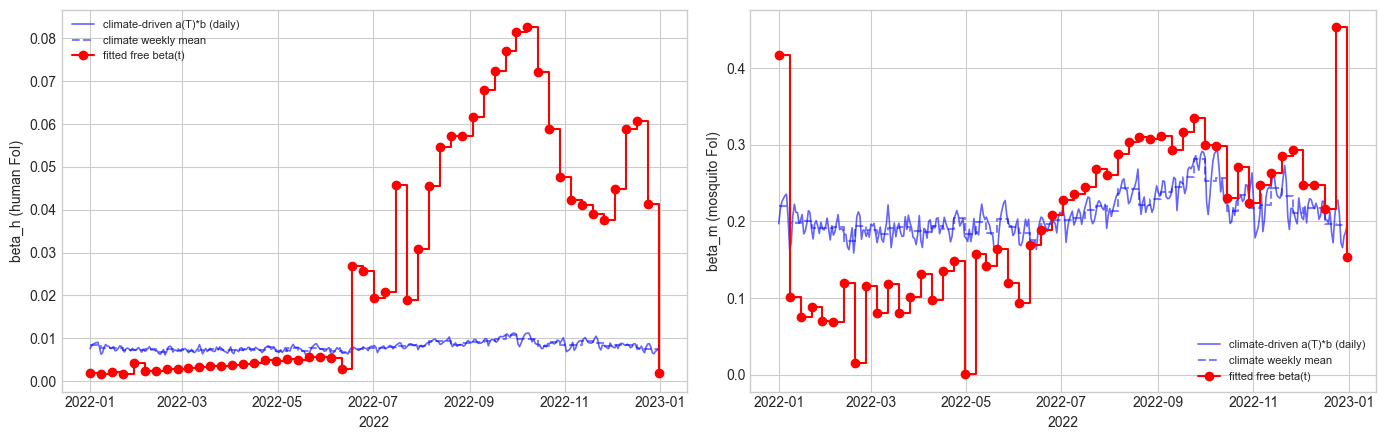

 week       date  beta_h_climate  beta_h_fitted  beta_m_climate  beta_m_fitted
    0 2022-01-01          0.0085         0.0019          0.2203         0.4174
    1 2022-01-08          0.0076         0.0018          0.1981         0.1009
    2 2022-01-15          0.0077         0.0020          0.2007         0.0747
    3 2022-01-22          0.0074         0.0016          0.1917         0.0890
    4 2022-01-29          0.0073         0.0043          0.1910         0.0698
    5 2022-02-05          0.0074         0.0024          0.1922         0.0692
    6 2022-02-12          0.0067         0.0023          0.1750         0.1190
    7 2022-02-19          0.0075         0.0028          0.1941         0.0149
    8 2022-02-26          0.0073         0.0029          0.1887         0.1157
    9 2022-03-05          0.0070         0.0030          0.1831         0.0811
   10 2022-03-12          0.0073         0.0033          0.1909         0.1188
   11 2022-03-19          0.0074         0.0036     

In [57]:
res = load_weekly_results(YEAR)
if res:
    # Get the fitted betas
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    bh_cli = np.array(res['beta_h_weekly_climate'])
    bm_cli = np.array(res['beta_m_weekly_climate'])
    nw = len(bh_fit)
    dates_year = observed_for_year(YEAR)['date']
    week_starts = dates_year[::7][:nw]
    
    bh_daily, bm_daily = climate_beta_daily(
        YEAR, res['climate_params']['b1'], res['climate_params']['b2']
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, name, fit, cli_week, cli_daily in [
        (axes[0], 'beta_h (human FoI)', bh_fit, bh_cli, bh_daily),
        (axes[1], 'beta_m (mosquito FoI)', bm_fit, bm_cli, bm_daily),
    ]:
        ax.plot(dates_year, cli_daily, 'b-', lw=1.2, alpha=0.6, 
                label='climate-driven a(T)*b (daily)')
        ax.step(week_starts, cli_week, 'b--', where='post', alpha=0.5, 
                label='climate weekly mean')
        ax.step(week_starts, fit, 'r-o', where='post', label='fitted free beta(t)')
        ax.set_ylabel(name)
        ax.set_xlabel(str(YEAR))
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    # Table
    tbl = pd.DataFrame({
        'week': np.arange(nw),
        'date': week_starts.values,
        'beta_h_climate': bh_cli,
        'beta_h_fitted': bh_fit,
        'beta_m_climate': bm_cli,
        'beta_m_fitted': bm_fit,
    })
    print(tbl.round(4).to_string(index=False))

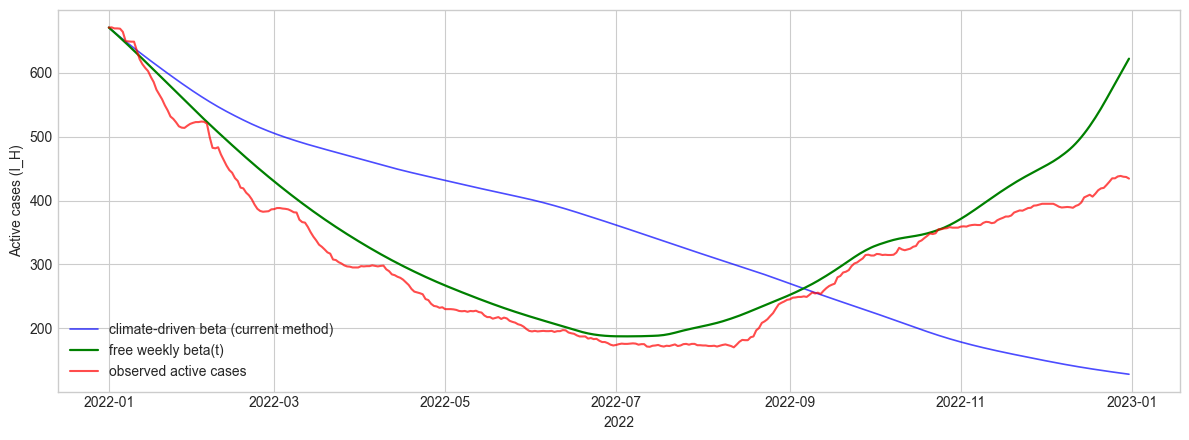

In [58]:
res = load_weekly_results(YEAR)
if res:
    fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    
    dates, IH, _ = simulate_year(YEAR, state0, fixed, bh_fit, bm_fit)
    obs = observed_for_year(YEAR)
    
    full = dict(fixed)
    full['b1'], full['b2'] = b1, b2
    dates0, IH0, _ = simulate_year(YEAR, state0, full)
    
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(pd.to_datetime(dates0), IH0, 'b-', lw=1.2, alpha=0.7, 
            label='climate-driven beta (current method)')
    ax.plot(pd.to_datetime(dates), IH, 'g-', lw=1.6, 
            label='free weekly beta(t)')
    ax.plot(obs['date'], obs['active_total'], 'r-', alpha=0.7, 
            label='observed active cases')
    ax.set_ylabel('Active cases (I_H)')
    ax.set_xlabel(str(YEAR))
    ax.legend()
    plt.tight_layout()
    plt.show()

### 2023

In [60]:
# ---------------------------------------------------------------------------
# Year Configuration
# ---------------------------------------------------------------------------
# Set the year you want to analyze (must have available data)
YEAR = 2023  # Change this to any year with available data (e.g., 2018, 2019, etc.)

# Validate year has data
try:
    obs = observed_for_year(YEAR)
    if len(obs) == 0:
        raise ValueError(f"No case data for year {YEAR}")
    start = f"{YEAR}-01-01"
    end = f"{YEAR}-12-31"
    clim = climate_data[
        (climate_data["date"] >= start) & (climate_data["date"] <= end)
    ]
    if len(clim) == 0:
        raise ValueError(f"No climate data for year {YEAR}")
    print(f"✓ Year {YEAR} has available data")
except Exception as e:
    print(f"✗ Error: {e}")
    print(f"Available years: {sorted(rural_cases_df['date'].dt.year.unique())}")

✓ Year 2023 has available data


In [61]:
fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
print(f'Fixed params for {YEAR} (from lmfit_results.json):')
for k, v in fixed.items():
    print(f'  {k:<8}= {v:.6g}')
print(f'Climate-driven scalars: b1={b1:.6g}, b2={b2:.6g}')
print('IC fractions:', {k: f'{v:.6g}' for k, v in fracs.items()})
print('Initial state:', state0)
print(f'Year days: {days_in_year(YEAR)}, weekly buckets: {n_weeks_in_year(YEAR)}')

Fixed params for 2023 (from lmfit_results.json):
  H0      = 20.1421
  k       = 0.207349
  phi     = 0.430717
  tau_H   = 19.8574
  gamma   = 0.0080641
  omega   = 0.0309537
  M_prime = 53616.2
Climate-driven scalars: b1=0.485177, b2=0.0100497
IC fractions: {'S_H0_frac': '1.18469', 'E_H0_frac': '0.00170469', 'I_M0_ratio': '0.00102592'}
Initial state: [9.40881690e+03 1.35386296e+01 4.43000000e+02 4.94023399e+01
 3.83149645e+04 6.25245503e+02 8.14789532e+01]
Year days: 365, weekly buckets: 53


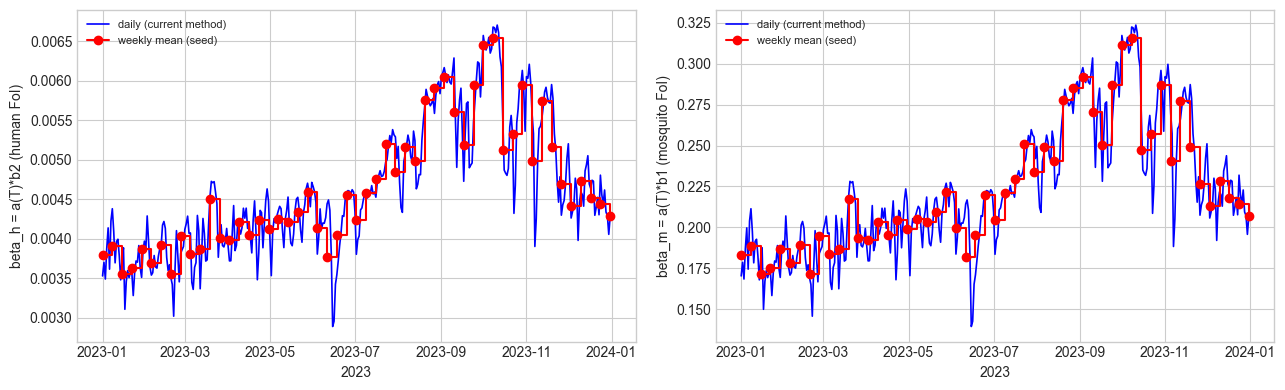

Climate beta_h weekly range: [0.00355, 0.00654]
Climate beta_m weekly range: [0.17152, 0.31555]


In [62]:
nw = n_weeks_in_year(YEAR)
bh_daily, bm_daily = climate_beta_daily(YEAR, b1, b2)
bh_week, bm_week = climate_beta_weekly(YEAR, b1, b2, nw)
dates_year = observed_for_year(YEAR)['date']
week_starts = dates_year[::7][:nw]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ylab, d, w in [
    (axes[0], 'beta_h = a(T)*b2 (human FoI)', bh_daily, bh_week),
    (axes[1], 'beta_m = a(T)*b1 (mosquito FoI)', bm_daily, bm_week),
]:
    ax.plot(dates_year, d, 'b-', lw=1.2, label='daily (current method)')
    ax.step(week_starts, w, 'r-o', where='post', label='weekly mean (seed)')
    ax.set_ylabel(ylab)
    ax.set_xlabel(str(YEAR))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'Climate beta_h weekly range: [{bh_week.min():.5f}, {bh_week.max():.5f}]')
print(f'Climate beta_m weekly range: [{bm_week.min():.5f}, {bm_week.max():.5f}]')

In [63]:
QUICK = False
MAX_NFEV = 300 if QUICK else 1200
WEIGHT_KW = dict(DEFAULT_WEIGHT_KW)

print(f'Fitting 2x{n_weeks_in_year(YEAR)} free weekly betas for {YEAR} with lmfit least_squares (max_nfev={MAX_NFEV})...')

payload = run_weekly_beta_fit(
    year=YEAR,  
    weight_kw=WEIGHT_KW,
    max_nfev=MAX_NFEV,
    verbose=True,
)

# Load results for display
res = load_weekly_results(YEAR)  # Updated function
if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")

Fitting 2x53 free weekly betas for 2023 with lmfit least_squares (max_nfev=1200)...
Year 2023: Baseline wMSE (climate-driven beta): 18,360.1
Fitting 106 free weekly betas (beta_h, beta_m)...
Fit done: wMSE = 7,597.8 (nfev=645, success=True)
Saved results to weekly_beta_results_2023.json
Year: 2023  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 18,360.1
Weekly-fit wMSE (free beta(t)): 7,597.8


In [64]:
res = load_weekly_results(YEAR)  

if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")
    if res['baseline_wmse'] > 0:
        reduction = (1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100
        print(f"wMSE reduction: {reduction:,.1f}%")
    print(f"lmfit: nfev={res['nfev']}, success={res['success']}, chisqr={res['chisqr']:.4g}")

Year: 2023  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 18,360.1
Weekly-fit wMSE (free beta(t)): 7,597.8
wMSE reduction: 58.6%
lmfit: nfev=645, success=True, chisqr=1.069e+07


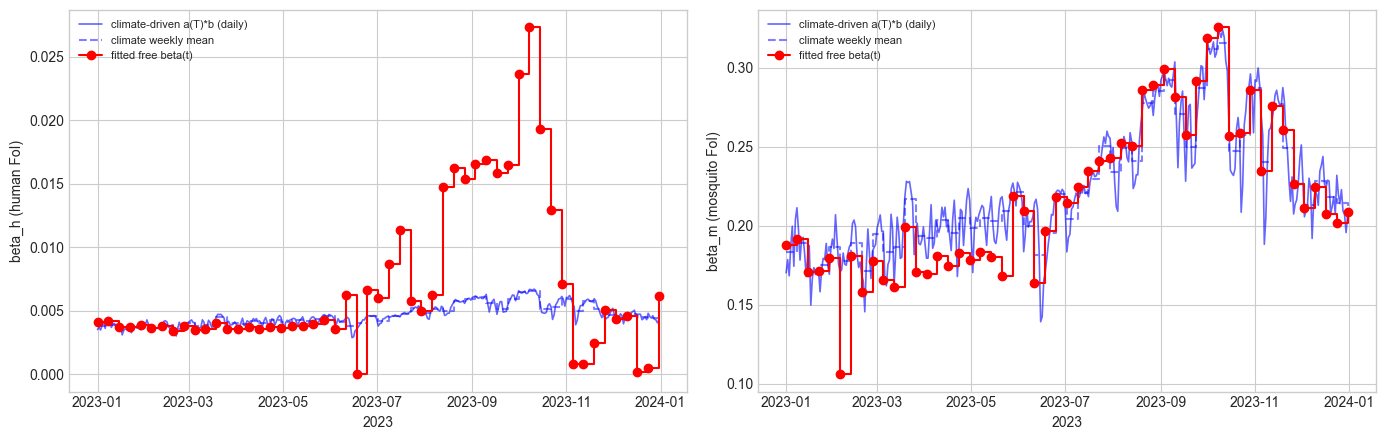

 week       date  beta_h_climate  beta_h_fitted  beta_m_climate  beta_m_fitted
    0 2023-01-01          0.0038         0.0041          0.1832         0.1875
    1 2023-01-08          0.0039         0.0042          0.1888         0.1917
    2 2023-01-15          0.0036         0.0037          0.1715         0.1709
    3 2023-01-22          0.0036         0.0037          0.1750         0.1712
    4 2023-01-29          0.0039         0.0039          0.1866         0.1797
    5 2023-02-05          0.0037         0.0036          0.1779         0.1062
    6 2023-02-12          0.0039         0.0038          0.1893         0.1809
    7 2023-02-19          0.0036         0.0034          0.1717         0.1584
    8 2023-02-26          0.0040         0.0038          0.1947         0.1780
    9 2023-03-05          0.0038         0.0035          0.1835         0.1655
   10 2023-03-12          0.0039         0.0035          0.1868         0.1614
   11 2023-03-19          0.0045         0.0041     

In [65]:
res = load_weekly_results(YEAR)
if res:
    # Get the fitted betas
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    bh_cli = np.array(res['beta_h_weekly_climate'])
    bm_cli = np.array(res['beta_m_weekly_climate'])
    nw = len(bh_fit)
    dates_year = observed_for_year(YEAR)['date']
    week_starts = dates_year[::7][:nw]
    
    bh_daily, bm_daily = climate_beta_daily(
        YEAR, res['climate_params']['b1'], res['climate_params']['b2']
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, name, fit, cli_week, cli_daily in [
        (axes[0], 'beta_h (human FoI)', bh_fit, bh_cli, bh_daily),
        (axes[1], 'beta_m (mosquito FoI)', bm_fit, bm_cli, bm_daily),
    ]:
        ax.plot(dates_year, cli_daily, 'b-', lw=1.2, alpha=0.6, 
                label='climate-driven a(T)*b (daily)')
        ax.step(week_starts, cli_week, 'b--', where='post', alpha=0.5, 
                label='climate weekly mean')
        ax.step(week_starts, fit, 'r-o', where='post', label='fitted free beta(t)')
        ax.set_ylabel(name)
        ax.set_xlabel(str(YEAR))
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    # Table
    tbl = pd.DataFrame({
        'week': np.arange(nw),
        'date': week_starts.values,
        'beta_h_climate': bh_cli,
        'beta_h_fitted': bh_fit,
        'beta_m_climate': bm_cli,
        'beta_m_fitted': bm_fit,
    })
    print(tbl.round(4).to_string(index=False))

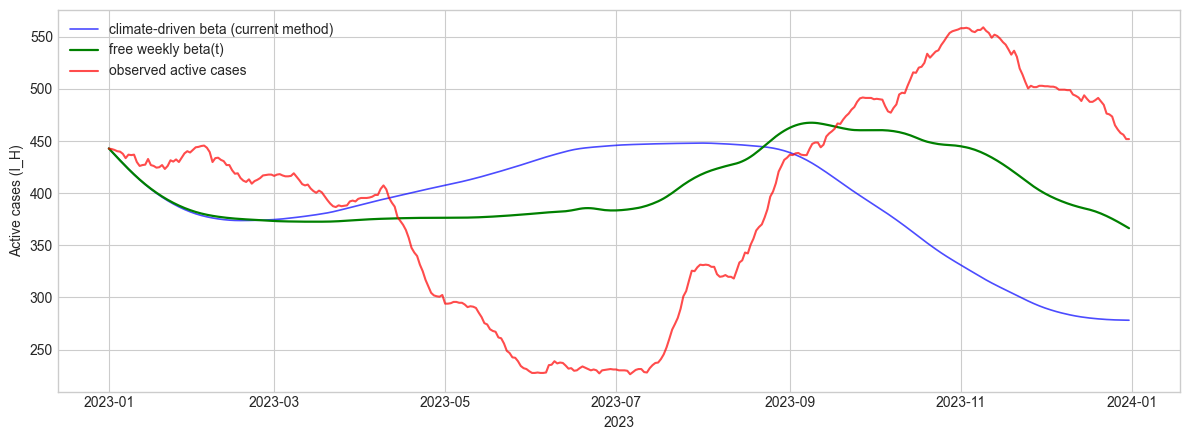

In [66]:
res = load_weekly_results(YEAR)
if res:
    fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    
    dates, IH, _ = simulate_year(YEAR, state0, fixed, bh_fit, bm_fit)
    obs = observed_for_year(YEAR)
    
    full = dict(fixed)
    full['b1'], full['b2'] = b1, b2
    dates0, IH0, _ = simulate_year(YEAR, state0, full)
    
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(pd.to_datetime(dates0), IH0, 'b-', lw=1.2, alpha=0.7, 
            label='climate-driven beta (current method)')
    ax.plot(pd.to_datetime(dates), IH, 'g-', lw=1.6, 
            label='free weekly beta(t)')
    ax.plot(obs['date'], obs['active_total'], 'r-', alpha=0.7, 
            label='observed active cases')
    ax.set_ylabel('Active cases (I_H)')
    ax.set_xlabel(str(YEAR))
    ax.legend()
    plt.tight_layout()
    plt.show()